# Tutorial 3 — JWST/NIRCam coronagraphy: HIP 65426 b with ADI + RDI (pyKLIP engine)

The ERS-1386 NIRCam observations of HIP 65426 (Carter et al. 2023) are the reference
JWST high-contrast data set: two science rolls through the MASK335R coronagraph and a
reference star (HIP 68245) observed in a 9-point small-grid dither.  With only ~10° of
roll this is an **RDI** problem — what matters is how the 18 reference frames are used,
not the field rotation.

spaceKLIP is the community pipeline for these data and hands them to pyKLIP; klip-tpe
plugs in at that hand-over: one partition per roll, the reference exposures as the RDI
library, pyKLIP's `klip_parallelized` as the engine, and the TPE search on top.

**Data.**  `tutorials/fetch_jwst_hip65426.py` pulls the F444W `calints` products from
MAST (no login, ~60 MB):
```
python3 -m pip install astroquery pyklip
python3 tutorials/fetch_jwst_hip65426.py            # --dry-run lists the files first
```
The notebook skips the run (and says so) when the files are not there.

In [1]:
import glob, os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig, datasets, stpsf_psf
from klip_tpe.reducer import Dataset, ReductionRequest
from klip_tpe.backends import spaceklip as sk
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay
from klip_tpe.metrics import MawetPeakSNR

DATA = os.path.expanduser(os.environ.get("KLIP_TPE_JWST", "~/.klip_tpe/data/jwst_hip65426"))
RUN_DIR = os.path.abspath("runs/hip65426_f444w")
# Re-running RESUMES this directory -- delete it to search again (see tutorial 01).
PLANET = (0.826, 150.2)                    # HIP 65426 b, Carter et al. 2023

files = sorted(glob.glob(os.path.join(DATA, "**", "jw*calints.fits"), recursive=True))
def _targ(f):
    h = fits.getheader(f)
    return str(h.get("TARGPROP", h.get("TARGNAME", ""))).replace("-", "").replace("_", "").upper()
sci_files = [f for f in files if _targ(f).startswith("HIP65426")]
ref_files = [f for f in files if f not in sci_files]
HAVE_DATA = len(sci_files) >= 2 and len(ref_files) >= 1
print(f"science exposures: {len(sci_files)}, reference exposures: {len(ref_files)}"
      f"  ({'ok' if HAVE_DATA else 'data not found - run the fetch script'})")

science exposures: 2, reference exposures: 9  (ok)


## 1. Stage-2 products need cleaning and alignment first

`*_calints.fits` come out of the JWST calibration pipeline *uncleaned*: hot and dead
pixels are flagged in the `DQ` extension but not repaired, and nothing has been aligned —
each small-grid-dither reference exposure sits at its own sub-pixel offset.  Subtracting
such references leaves a residual far brighter than any planet (try it: the planet is
undetectable without this section).

**In production, use spaceKLIP's `ImageTools`** (`quick_cleaning`, `align_frames`, …),
which does this properly and writes `STARCENX/Y` into the headers; `load_spaceklip` then
reads its products directly (section 6).  So that this notebook stands alone, here is the
minimal version: fill the flagged pixels from their neighbours, then register every frame
on the median science frame by FFT cross-correlation.

**Fill the flagged pixels and nothing else.**  A coronagraphic PSF is *supposed* to be
full of sharp, isolated blobs — the six-lobed Lyot-stop pattern of the star, and for a
companion behind MASK335R a three-bar "hamburger" core (Carter et al. 2023, Fig. 3).  Any
repair that decides from the pixel *values* what is an outlier — a median filter with a
sigma clip against the frame's scatter, which is set by empty sky — will rewrite the PSF:
on these frames such a filter touched ~5,000 pixels per frame of which only ~1,560 were
flagged, and turned HIP 65426 b into one smeared blob at a third of its peak.  Until
2026-09-16 this notebook and `load_calints` did exactly that.

4 science integrations at PA [110.3 120.4] deg, 18 reference integrations, 320x320 px


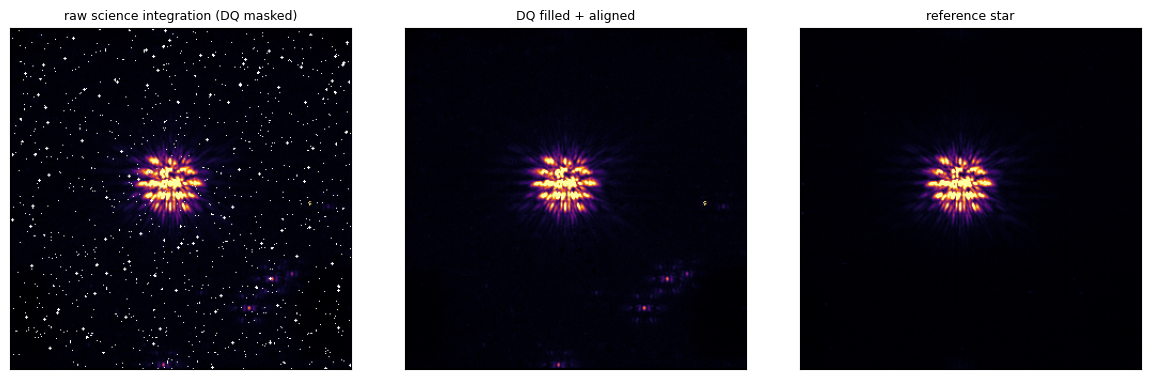

In [2]:
def read_calints(paths):
    """(frames, position angles) from stage-2 products; DQ=DO_NOT_USE pixels -> NaN."""
    ims, pas = [], []
    for f in paths:
        with fits.open(f) as h:
            d = np.asarray(h["SCI"].data, float)
            dq = np.asarray(h["DQ"].data, int) if "DQ" in h else np.zeros_like(d, int)
            s = h["SCI"].header
            pa = float(s["ROLL_REF"]) - float(s.get("V3I_YANG", 0.0)) * float(s.get("VPARITY", 1))
            d = np.where((dq & 1).astype(bool), np.nan, d)          # bit 0 = DO_NOT_USE
            for i in range(d.shape[0]):                             # one entry per integration
                ims.append(d[i]); pas.append(pa)
    return np.array(ims), np.array(pas)

def repair(cube, maxit=20):
    """Fill every DQ-flagged (NaN) pixel with the median of its finite 8 neighbours --
    spaceKLIP's treatment -- and touch nothing else.  Clusters close from the rim inward."""
    out = np.array(cube, float)
    for i, im in enumerate(out):
        for _ in range(maxit):
            bad = ~np.isfinite(im)
            if not bad.any():
                break
            p = np.pad(im, 1, constant_values=np.nan)
            st = np.stack([p[1 + dy:1 + dy + im.shape[0], 1 + dx:1 + dx + im.shape[1]]
                           for dy in (-1, 0, 1) for dx in (-1, 0, 1) if (dy, dx) != (0, 0)])
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)          # all-NaN stencils inside a cluster
                im[bad] = np.nanmedian(st, axis=0)[bad]
        out[i] = im
    return out

def xcorr_shift(im, ref, search=6):
    """Sub-pixel (dx, dy) that brings `im` onto `ref` (FFT cross-correlation + parabola)."""
    cc = np.fft.fftshift(np.fft.irfft2(np.fft.rfft2(im) * np.conj(np.fft.rfft2(ref)), s=im.shape))
    c = np.array(im.shape) // 2
    sub = cc[c[0] - search:c[0] + search + 1, c[1] - search:c[1] + search + 1]
    k = np.unravel_index(np.argmax(sub), sub.shape)
    dy, dx = k[0] - search, k[1] - search
    par = lambda a, b, c_: 0.0 if (a - 2 * b + c_) == 0 else 0.5 * (a - c_) / (a - 2 * b + c_)
    if 0 < k[0] < sub.shape[0] - 1: dy += par(sub[k[0] - 1, k[1]], sub[k[0], k[1]], sub[k[0] + 1, k[1]])
    if 0 < k[1] < sub.shape[1] - 1: dx += par(sub[k[0], k[1] - 1], sub[k[0], k[1]], sub[k[0], k[1] + 1])
    return dx, dy

def align(cube, ref):
    out = np.empty_like(cube)
    for i, im in enumerate(cube):
        dx, dy = xcorr_shift(im, ref)
        out[i] = ndimage.shift(im, (-dy, -dx), order=3, mode="constant", cval=0.0)
    return out

if HAVE_DATA:
    sci_raw, pas = read_calints(sci_files)
    ref_raw, _ = read_calints(ref_files)
    print(f"{sci_raw.shape[0]} science integrations at PA {np.unique(np.round(pas, 1))} deg, "
          f"{ref_raw.shape[0]} reference integrations, {sci_raw.shape[1]}x{sci_raw.shape[2]} px")
    sci_c, ref_c = repair(sci_raw), repair(ref_raw)
    anchor = np.median(sci_c, axis=0)
    sci_a, ref_a = align(sci_c, anchor), align(ref_c, anchor)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
    for a, im, t in zip(ax, (sci_raw[0], sci_a[0], ref_a[0]),
                        ("raw science integration (DQ masked)", "DQ filled + aligned", "reference star")):
        v = np.nanpercentile(im[np.isfinite(im)], [5, 99.5])
        a.imshow(im, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1]); a.set_title(t, fontsize=9)
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()

## 2. Partitions: one per roll, references as the RDI library

klip-tpe expects the star at the centre of the array, so the crop is taken about it.  Each
roll becomes a `Dataset` with its own parameter block, and both carry the same reference cube.

**`CRPIX` is where the mask is, not where the star is.**  It is the *aperture reference
point* — identical in every file of the programme, dithers included — and on these frames it
misses HIP 65426 by **0.78 px**, which throws the companion 0.8 px inside its own separation
and, worse, mismatches its KLIP throughput against the fakes injected to calibrate it.

Three ways to find the star, two of which fail here: there is no off-axis stellar image
anywhere in the programme to centroid (HIP 65426 *and* the reference star φ Cen are behind
MASK335R in every exposure), and a 180° symmetry fit to the coronagraphic residual is too
speckle-dominated — it moved the centre by 2 px between the two rolls of these very data.
What works is the companion itself: derotating about a centre that is wrong by `δ` puts it at
`u + R(PA_k)·δ` in roll `k`, so each roll gives `δ = R(−PA_k)·(measured − expected)`
independently, and the two agree to 0.12 px (on the median-filtered frames of section 1's
warning they disagreed by 0.71 px — the smear had moved the peak).  `datasets.PHOTOMETRY` carries the answer and
`scripts/check_hip65426_contrast.py` is the solve; the proper source is spaceKLIP's own
star-centring step (`STARCENX/Y`), which section 6's path uses.

Note this fixes the *geometry* only.  It leaves the contrast axis alone — that is section 3.

In [3]:
if HAVE_DATA:
    hdr = fits.getheader(sci_files[0], "SCI")
    pxscale = float(np.sqrt(hdr["PIXAR_A2"]))                      # 0.0626"/px (NIRCam LW)
    pixar_sr = float(hdr["PIXAR_SR"])                              # for the flux scale, section 3
    wavelength = 4.44e-6                                           # F444W pivot
    PHOT = datasets.PHOTOMETRY["hip65426_f444w"]
    cx, cy = PHOT["star_center"]                                   # NOT CRPIX -- see above
    print(f"CRPIX ({hdr['CRPIX1']-1:.2f}, {hdr['CRPIX2']-1:.2f}) vs the star at "
          f"({cx:.2f}, {cy:.2f}): {np.hypot(cx-hdr['CRPIX1']+1, cy-hdr['CRPIX2']+1):.2f} px apart")
    H = 55                                                          # 111x111 px = 6.9" square

    def crop(cube):
        # ODD size, deliberately.  The shift puts the star on the integer pixel round(cx),
        # and the crop starts H pixels before it, so the star lands on index H -- which is
        # the array centre (n-1)/2 only when n = 2H+1.  With an even 2H crop the star sits
        # half a pixel off the centre klip-tpe assumes in EVERY axis (0.71 px in all), and
        # every separation and position angle downstream is measured from the wrong origin.
        fx, fy = cx - round(cx), cy - round(cy)
        x0, y0 = int(round(cx)) - H, int(round(cy)) - H
        return np.array([ndimage.shift(im, (-fy, -fx), order=3)[y0:y0 + 2 * H + 1, x0:x0 + 2 * H + 1]
                         for im in cube], np.float32)

    sci_x, ref_x = crop(sci_a), crop(ref_a)
    dsets = {}
    for k, pa in enumerate(np.unique(np.round(pas, 1))):
        m = np.round(pas, 1) == pa
        dsets[f"roll{k + 1}"] = Dataset(sci_x[m], pas[m], name=f"roll{k + 1}", ref_cube=ref_x,
                                        meta={"pxscale": pxscale, "wavelength_m": wavelength})
    for pid, d in dsets.items():
        print(f"{pid}: {d.cube.shape[0]} integrations, PA {d.angles[0]:.1f} deg, "
              f"RDI library {d.ref_cube.shape[0]} frames")

CRPIX (149.20, 173.60) vs the star at (149.65, 172.96): 0.78 px apart


roll1: 2 integrations, PA 110.3 deg, RDI library 18 frames
roll2: 2 integrations, PA 120.4 deg, RDI library 18 frames


## 3. Reducer, space, objective

`spaceklip.make_reducer` builds one `PyKLIPReducer` per partition, with λ/D from the
filter and D = 6.5 m.  The searched block per roll is small here — the high-pass filter,
`n_ang` (pyKLIP `subsections`) and `k_klip` (`numbasis`) — because `make_space` scales the
ranges to the data: with two integrations per roll there is nothing to bin and no angular
exclusion worth searching.

On top of that we add one *global categorical* dimension: pyKLIP's **`mode`**
(`ADI`, `RDI`, `ADI+RDI`).  Any `Param` whose name matches a backend option is passed
straight through to the engine, so the optimizer can decide how to use the reference
library — and with a 10° roll that decision matters: in `ADI+RDI` the other roll enters
the basis at ~1 FWHM of planet motion and self-subtracts the companion (two cells down:
S/N 12 → 1 at k = 10 in this annulus; in the whole-image 20-mode reduction of Carter et
al.'s Fig. 3 it keeps half the flux, against 0.8 for pure `RDI`), which is why Carter et
al. quote their photometry from forward-modelled fits rather than from the images.

**The contrast axis.** HIP 65426 is behind the mask in every exposure and so is the
reference star, so the star's brightness has to be imported — and with a coronagraph the
import has four terms that are easy to confuse:

| term | value | from |
|---|---|---|
| `S` | 0.4026 Jy | synthetic photometry: Planck(8600 K) through F444W, normalised to 2MASS Ks = 6.771 |
| units | `S / (10⁶·PIXAR_SR)` | `BUNIT = MJy/sr` and `PIXAR_SR` from the header |
| `EE` | 0.696 at 16.5 px | the model PSF **unocculted through the Lyot stop** — an *imaging* PSF gives 0.928 and counts the stop twice |
| `T_optics` | 1.0 | nothing left to add: `PHOTMJSR` for `PUPIL=MASKRND` already carries the coronagraphic optics |

and one term that is deliberately **not** in `flux_unit`: the occulter's spatial
transmission `T(ρ)`, which multiplies it inside `inject_sources`.  Folding it into the star
flux, or applying it twice, is the classic coronagraphic error.

Why `T_optics` is 1: STPSF's `calc_psf` defaults to `normalize='first'` — normalise at the
*entrance pupil* and propagate only diffractive losses — which is what makes the grid's
measured `transmission` a real number (`normalize='last'` would report `T ≈ 1` everywhere).
The model therefore lacks the COM substrate and the Lyot substrate, but so did every flux
standard observed through them: `PHOTMJSR` for this pupil (2.486, against ~0.4 for CLEAR
imaging) was derived in this very optical train, so the MJy/sr in the file already put an
off-mask source at its true flux, and `EE` is a *fraction* of the Lyot-stop PSF in which the
stop's own 0.18 cancels.  The proof is the planet: with nothing tuned, HIP 65426 b measures
ΔF444W = 8.74 ± 0.09 against Carter et al. (2023)'s 8.703 ± 0.055
(`scripts/check_hip65426_contrast.py`).  Until 2026-09-16 a `T_optics` of 0.561 sat here,
"anchored" on the companion — it was compensating for the median-filter damage described in
section 1, not for any optics.  See `docs/FLUX_CALIBRATION.md`.

In [4]:
STAR_FLUX, PSF_MODEL = None, None
if HAVE_DATA and stpsf_psf.have_stpsf():
    grid = stpsf_psf.offaxis_grid("NIRCam", "F444W", image_mask="MASK335R",
                                  seps_as=np.arange(0.2, 3.01, 0.2), stamp_px=41, nlambda=3)
    STAR_FLUX = stpsf_psf.star_flux_from_flux_density(
        grid, PHOT["flux_density_jy"], pixar_sr,
        optics_transmission=PHOT["optics_transmission"])
    PSF_MODEL = stpsf_psf.library(grid, star_flux=STAR_FLUX)
elif HAVE_DATA:
    print("STPSF unavailable -- falling back to a Gaussian of flux unit 1: parameter *ranking*"
          "\nis unaffected, only the contrast axis becomes arbitrary (template units).")

if HAVE_DATA:
    from klip_tpe import Param
    red = sk.make_reducer(dsets, injection_model=PSF_MODEL, mode="RDI",
                          max_workers="auto")          # pool="threads": pyKLIP forks its own workers
    space = generic.make_space(red, k_klip_max=18, search_angles=False)
    space.add(Param("mode", 0, 2, "categorical", choices=["ADI", "RDI", "ADI+RDI"], default="RDI",
                    doc="pyKLIP PSF-subtraction mode"))
    space.project = generic.make_guard(red, k_max=18, n_min_ref=4)
    objective, sampler = generic.default_config(red, known=[PLANET])
    print(space.names)

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-073 CANNOT BE CHECKED AGAINST ONLINE VERSION


  stpsf: 15 off-axis PSFs from cache stpsf_NIRCam_F444W_MASK335R_e51cfe4c25d32c8d.fits
  stpsf: S = 0.4026 Jy -> 4.3715e+06 MJy/sr summed over the PSF; EE(16.50 px) = 0.6960; optics transmission 1.0000 -> star_flux = 3.0424e+06
  roll1: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection library
  roll2: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection library
['bin_roll1', 'n_ang_roll1', 'filter_roll1', 'k_klip_roll1', 'bin_roll2', 'n_ang_roll2', 'filter_roll2', 'k_klip_roll2', 'drop1', 'drop2', 'mode']


A default RDI reduction with 10 KL modes: HIP 65426 b is the point source at 0.83″,
PA 150° (circled).  Look at its shape: a three-bar "hamburger" core with six faint lobes
around it, exactly as in Carter et al. (2023)'s Fig. 3 — that is what an off-axis source
behind MASK335R looks like through the round Lyot stop, not two sources.  (Try
`mode="ADI+RDI"` here to see the companion fade.)

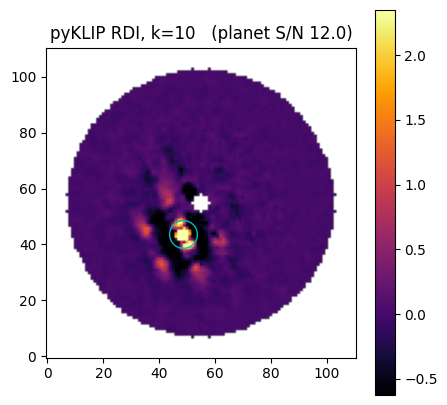

In [5]:
if HAVE_DATA:
    cfg0 = space.decode(space.default_vector())
    res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=6, outrad=45, k_klip=10, mode="RDI")))
    metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)
    c = (res.image.shape[0] - 1) / 2.0
    xb = c - PLANET[0] / pxscale * np.sin(np.deg2rad(PLANET[1]))
    yb = c + PLANET[0] / pxscale * np.cos(np.deg2rad(PLANET[1]))
    snr0 = float(metric.per_source(res.image, None, [PLANET[0]], [PLANET[1]])[0])
    plt.figure(figsize=(5, 5)); v = np.nanpercentile(res.image[np.isfinite(res.image)], [2, 99.7])
    plt.imshow(res.image, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1])
    plt.plot(xb, yb, "o", mfc="none", mec="c", ms=20); plt.colorbar()
    plt.title(f"pyKLIP RDI, k=10   (planet S/N {snr0:.1f})")

In [6]:
if HAVE_DATA:                                    # the same reduction in ADI and ADI+RDI: the roll pair self-subtracts
    for m in ("ADI", "RDI", "ADI+RDI"):
        im = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=6, outrad=45, k_klip=10, mode=m))).image
        print(f"mode={m:8s} planet S/N {float(metric.per_source(im, None, [PLANET[0]], [PLANET[1]])[0]):5.1f}")

mode=ADI      planet S/N  -0.2


mode=RDI      planet S/N  12.0


mode=ADI+RDI  planet S/N   1.2


## 4. Optimize

50 evaluations, the best two validated on three fresh injection sets each.  Each
evaluation injects companions into the *science* frames only — the reference library is
never contaminated — reduces with and without them and scores the difference.

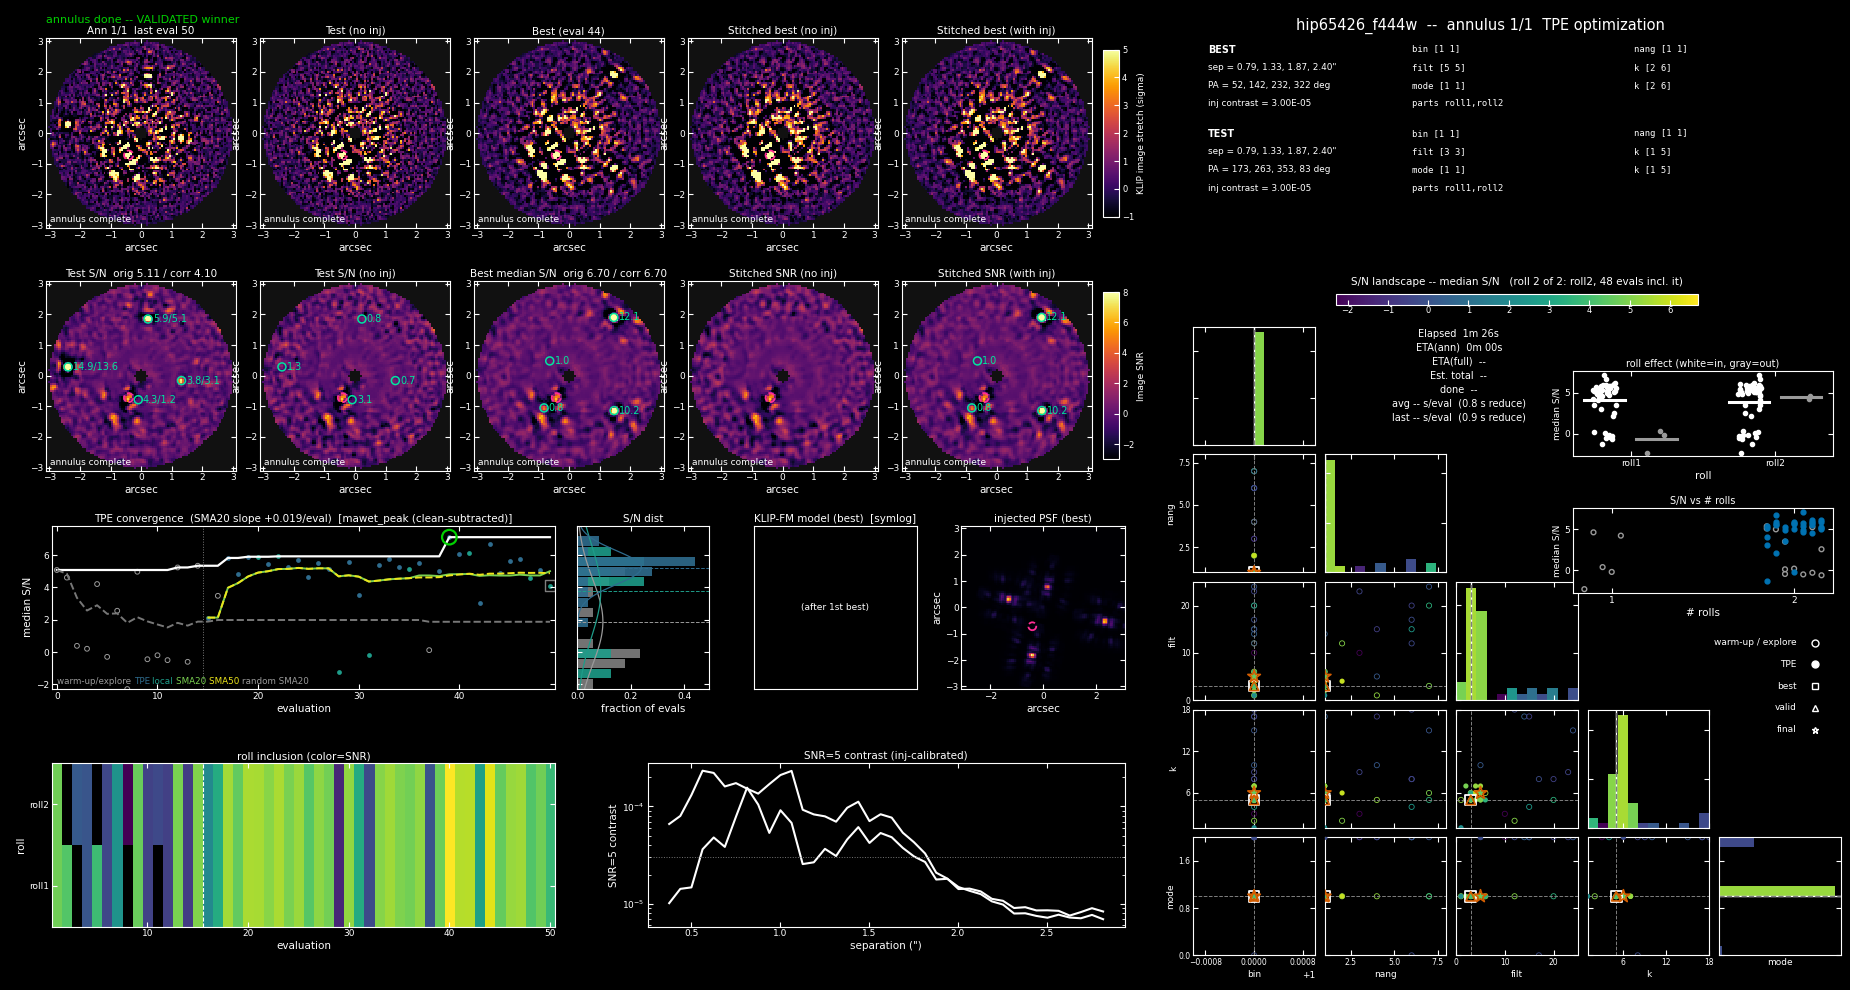

=== annulus 1/1: [6.0, 45.0] px, 4 sources, band 0.520-2.672"


  calibration k-scan: k_default = 2


  calibration trial 1: contrast=3.000e-05  median S/N=4.42


[ann 1] eval 2/50 warmup  score=4.611 raw=5.764 best=5.080@1  contrast=3.00e-05  reduce 0s / loop 1s  (0.00 h)


  [display] a panel takes longer to draw than an evaluation takes to run, so some evaluations are going without one -- this keeps the window showing the current state instead of falling further behind. The run is unaffected; draw every panel afterwards with  klip-tpe render --run-dir /home/claude/klip-tpe-py/tutorials/runs/hip65426_f444w
[ann 1] eval 3/50 warmup  score=0.383 raw=1.291 best=5.080@1  contrast=3.00e-05  reduce 1s / loop 1s  (0.00 h)


...

  annulus 1 winner: eval 44, validated score 5.559
param_verify config 1/2 (eval 40, score 7.11)


param_verify config 2/2 (eval 38, score 0.12)


param_verify annulus 01: 2 configs; combine K~4.882E+03


run complete: 1 annuli, 50 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/hip65426_f444w/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/hip65426_f444w/opt_steps.mp4']
1.6 min


In [7]:
if HAVE_DATA:
    cfg = RunConfig(ann_edges=[6, 45], n_iter=50, n_init=15, seed=5, n_sources=4,
                    validation=ValidationConfig(n_top=2, n_valid=3),
                    calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                    defaults={"k_klip": 10}, fm_curve=False)        # KLIP-FM: built-in engine only
    display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, every=2, movie_every=10)
    runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
    t0 = time.time(); results = runner.run(); print(f"{(time.time() - t0) / 60:.1f} min")

winner: eval 44, validated True, injected S/N 5.56   rolls kept: ['roll1', 'roll2']
  mode = RDI
  roll1: n_ang=1  filter=5  k_klip=2
  roll2: n_ang=1  filter=5  k_klip=6
HIP 65426 b: S/N 12.0 (default)  ->  12.9 (validated winner)


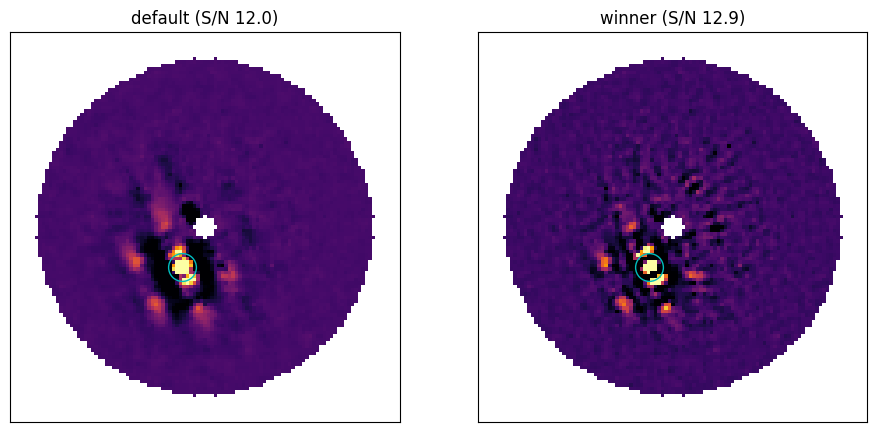

In [8]:
if HAVE_DATA:
    r = results[0]
    print(f"winner: eval {r.winner_index + 1}, validated {r.validated}, injected S/N {r.winner_score:.2f}"
          f"   rolls kept: {r.partitions}")
    print(f"  mode = {r.winner_config['params'].get('mode')}")
    for pid, blk in r.winner_config["per_partition"].items():
        print(f"  {pid}: " + "  ".join(f"{k}={v}" for k, v in blk.items() if k in ("filter", "n_ang", "k_klip")))
    best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
    snr1 = float(metric.per_source(best_clean, None, [PLANET[0]], [PLANET[1]])[0])
    print(f"HIP 65426 b: S/N {snr0:.1f} (default)  ->  {snr1:.1f} (validated winner)")
    fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.4))
    for a, im, t in zip(ax, (res.image, best_clean), (f"default (S/N {snr0:.1f})", f"winner (S/N {snr1:.1f})")):
        v = np.nanpercentile(im[np.isfinite(im)], [2, 99.7])
        a.imshow(im, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1]); a.set_title(t)
        a.plot(xb, yb, "o", mfc="none", mec="c", ms=20); a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()

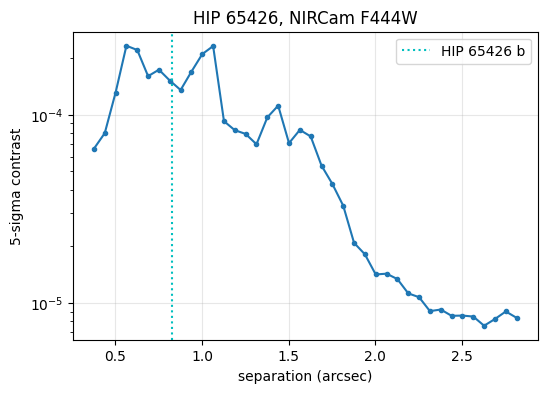

In [9]:
if HAVE_DATA:
    cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
    plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3)
    plt.axvline(PLANET[0], color="c", ls=":", label="HIP 65426 b")
    plt.xlabel("separation (arcsec)")
    plt.ylabel("5-sigma contrast" + ("" if STAR_FLUX else " (template units)"))
    plt.grid(alpha=.3); plt.legend(); plt.title("HIP 65426, NIRCam F444W");

## 5. The real PSF, and a forward-modelled matched filter

Two approximations are worth removing on JWST.  First the **injected PSF**: inside a few
λ/D of a coronagraph the off-axis PSF is neither a Gaussian nor separation-independent,
and the mask throughput is a steep function of separation.
[STPSF](https://stpsf.readthedocs.io) (the renamed WebbPSF) computes both from the mode in
the headers — `psf="stpsf"` in `make_reducer`, or by hand below.  The grid is cached, so
the cost is paid once.

Second the **matched filter**.  KLIP is not flux-conserving: it eats part of the planet
and leaves negative lobes around what is left, by an amount that depends on the very
parameters being searched.  `klip_tpe.fmmf.FMMFSNR` propagates the PSF model through each
configuration's own subtraction and filters with *that* (Pueyo 2016; Ruffio et al. 2017).
Everything else — the Mawet small-sample ring statistics, the clean-subtraction rule, the
validation protocol — is untouched, so the two runs differ only in the filter.

  stpsf: 15 off-axis PSFs from cache stpsf_NIRCam_F444W_MASK335R_7b215d8d8edaba8e.fits
throughput at the planet: 0.778


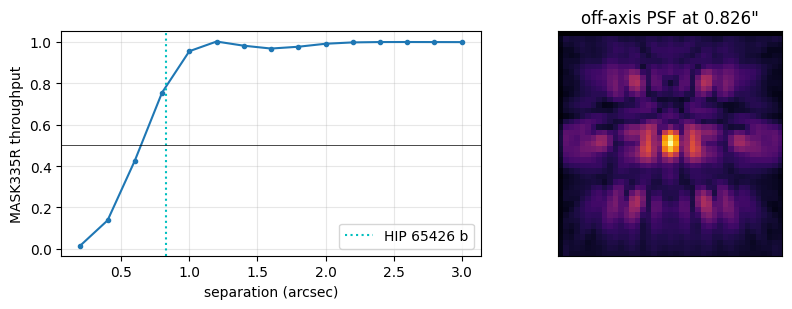

In [10]:
if HAVE_DATA:
    try:
        # The grid has to span the SEARCH ANNULUS, not just the planet: the injections are
        # spread from the inner to the outer edge, and `LibraryPSF` has no template outside
        # its own range, so a source past the last separation aborts that evaluation.  Built
        # only out to 2.0" while the annulus reaches 45 px = 2.82", every one of 50
        # evaluations failed -- the run finished with no winner and no best image.
        grid = stpsf_psf.offaxis_grid("NIRCam", "F444W", image_mask="MASK335R",
                                      seps_as=np.arange(0.2, 45 * pxscale + 0.21, 0.2),
                                      stamp_px=21, nlambda=1)
        psf_model = PSF_MODEL or stpsf_psf.library(grid, star_flux=STAR_FLUX or 1.0)
        plt.figure(figsize=(9, 3.2))
        plt.subplot(1, 2, 1)
        plt.plot(grid["seps"], grid["transmission"], "-o", ms=3)
        plt.axvline(PLANET[0], color="c", ls=":", label="HIP 65426 b")
        plt.axhline(0.5, color="k", lw=.5)
        plt.xlabel("separation (arcsec)"); plt.ylabel("MASK335R throughput")
        plt.legend(); plt.grid(alpha=.3)
        plt.subplot(1, 2, 2)
        st, _, _ = psf_model.stamp(PLANET[0])
        plt.imshow(st ** 0.4, origin="lower", cmap="inferno")
        plt.title(f'off-axis PSF at {PLANET[0]}"'); plt.xticks([]); plt.yticks([])
        plt.tight_layout()
        print(f"throughput at the planet: {psf_model.throughput(PLANET[0]):.3f}")
    except Exception as exc:            # STPSF and its data files are an optional dependency
        psf_model = None
        print(f"STPSF unavailable ({exc}); keeping the Gaussian template")

The same 50-evaluation search, scored with the forward-modelled filter.  pyKLIP has no
analytic KLIP-FM, so the template is the *numerical* forward model `injected − clean` —
the same response to first order, and free, because the clean reduction is computed
anyway.  `fm_fraction` says what fraction of the filters really were forward-modelled.

  roll1: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection library
  roll2: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection library


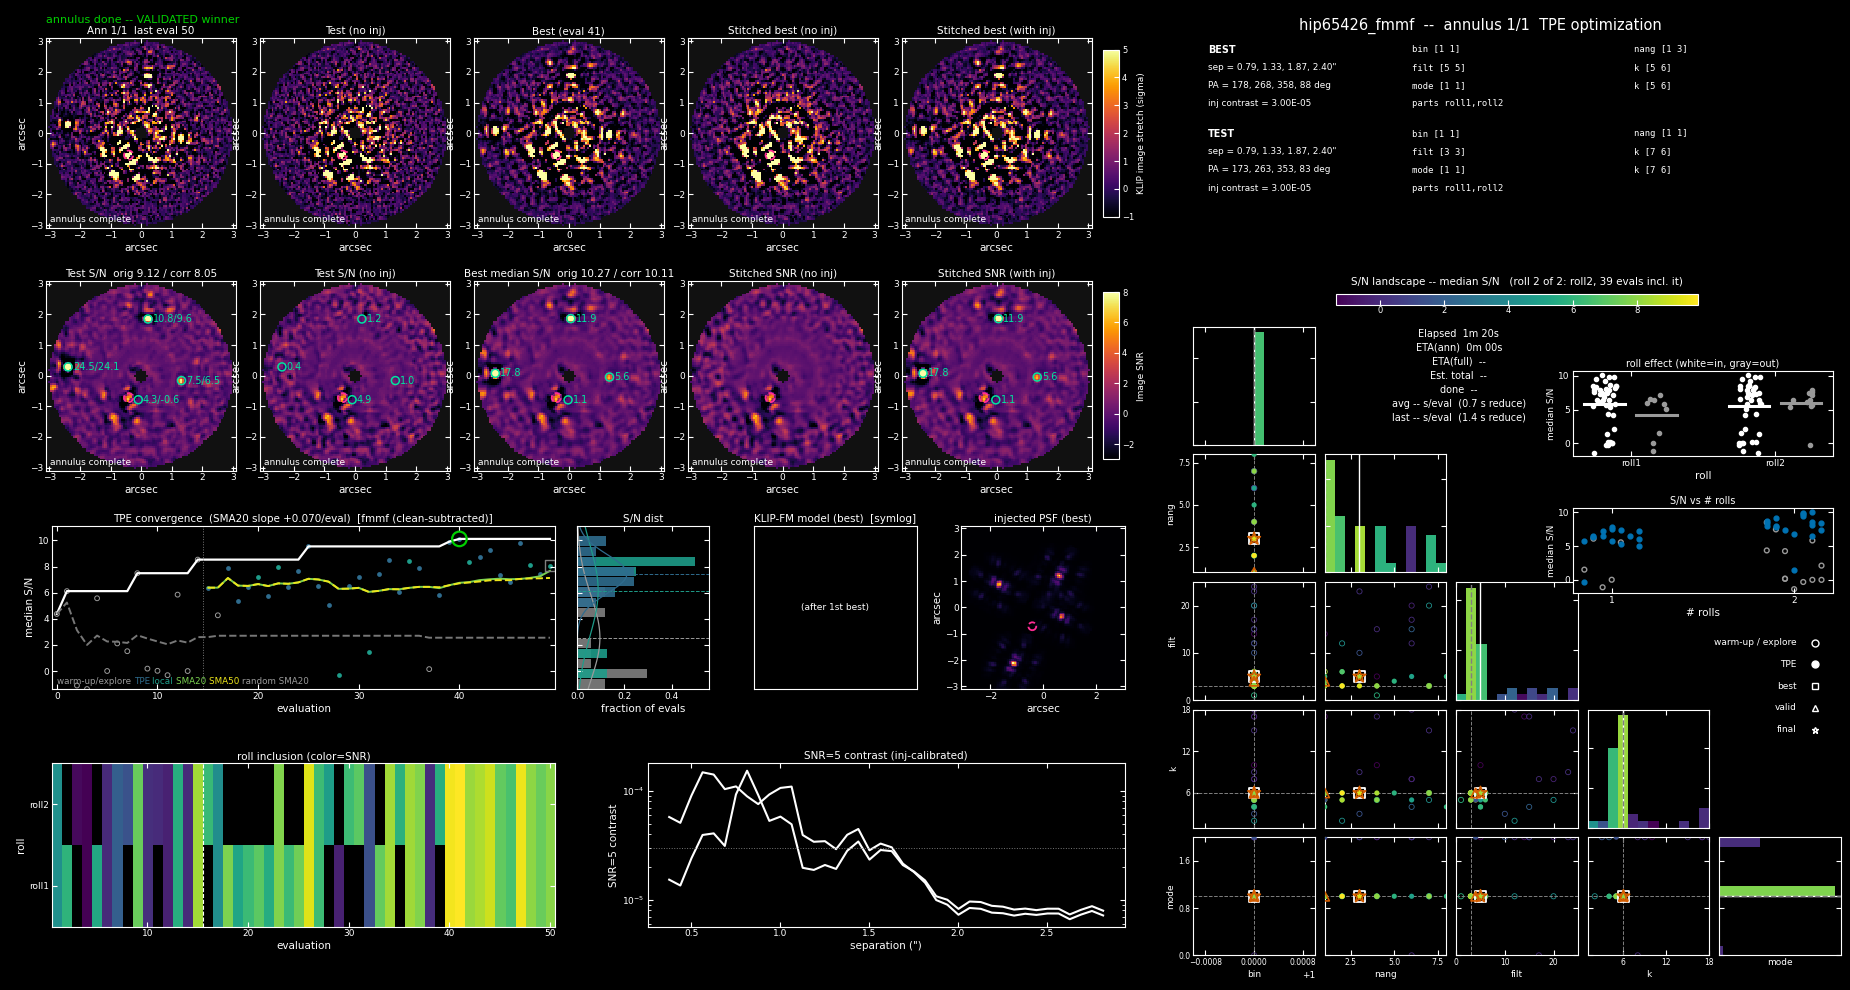

=== annulus 1/1: [6.0, 45.0] px, 4 sources, band 0.520-2.672"


  calibration k-scan: k_default = 2


  calibration trial 1: contrast=3.000e-05  median S/N=4.26


  [display] a panel takes longer to draw than an evaluation takes to run, so some evaluations are going without one -- this keeps the window showing the current state instead of falling further behind. The run is unaffected; draw every panel afterwards with  klip-tpe render --run-dir /home/claude/klip-tpe-py/tutorials/runs/hip65426_fmmf
[ann 1] eval 2/50 warmup  score=6.117 raw=6.828 best=6.117@2  contrast=3.00e-05  reduce 1s / loop 1s  (0.00 h)


[ann 1] eval 3/50 warmup  score=-1.101 raw=0.842 best=6.117@2  contrast=3.00e-05  reduce 0s / loop 0s  (0.00 h)


...

param_verify config 1/2 (eval 41, score 10.11)


param_verify config 2/2 (eval 32, score 1.44)


param_verify annulus 01: 2 configs; combine K~7.087E+03


run complete: 1 annuli, 50 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/hip65426_fmmf/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/hip65426_fmmf/opt_steps.mp4']
1.5 min
forward-modelled filters: 53% of 832


In [11]:
if HAVE_DATA:
    from klip_tpe.fmmf import FMMFSNR
    red_fm = sk.make_reducer(dsets, injection_model=psf_model,
                             mode="RDI", max_workers="auto")
    objective_fm, _ = generic.default_config(red_fm, metric="fmmf", known=[PLANET])
    metric_fm = objective_fm.metric
    cfg_fm = RunConfig(ann_edges=[6, 45], n_iter=50, n_init=15, seed=5, n_sources=4,
                       validation=ValidationConfig(n_top=2, n_valid=3),
                       calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                       defaults={"k_klip": 10}, fm_curve=False)
    run_fm = os.path.join(os.path.dirname(RUN_DIR), "hip65426_fmmf")
    runner_fm = Runner(red_fm, space, objective_fm, sampler, cfg_fm, run_fm,
                       callbacks=[LiveDisplay(run_fm, show="inline", window_scale=0.55, every=5)])
    t0 = time.time(); results_fm = runner_fm.run(); print(f"{(time.time() - t0) / 60:.1f} min")
    print(f"forward-modelled filters: {metric_fm.describe()['fm_fraction']:.0%} of "
          f"{metric_fm.describe()['n_filtered']}")

In [12]:
if HAVE_DATA:
    fm_clean = fits.getdata(os.path.join(run_fm, "annulus01", "best_clean.fits"))
    snr2 = float(metric.per_source(fm_clean, None, [PLANET[0]], [PLANET[1]])[0])
    print(f"HIP 65426 b, scored the same way for all three images:")
    print(f"   default k=10        S/N {snr0:5.1f}")
    print(f"   PSF matched filter  S/N {snr1:5.1f}")
    print(f"   forward-modelled MF S/N {snr2:5.1f}")
    print(f"   winner (fmmf): " + "  ".join(
        f"{k}={v}" for k, v in results_fm[0].winner_config["params"].items()
        if k in ("mode", "filter", "n_ang", "k_klip")))

HIP 65426 b, scored the same way for all three images:
   default k=10        S/N  12.0
   PSF matched filter  S/N  12.9
   forward-modelled MF S/N  12.5
   winner (fmmf): n_ang=2  filter=5  k_klip=6  mode=RDI


## 6. Notes for real JWST work

* **Preprocessing sets the floor.**  Section 1 is the bare minimum; spaceKLIP's
  `ImageTools` (bad-pixel repair, background subtraction, sub-pixel alignment on the
  diffraction pattern, frame selection) does better, and the optimizer works with whatever
  floor it is given.
* **Photometry.**  Pass an off-axis PSF and the star flux for contrasts in physical units
  rather than template units.
* **Small data sets.**  With four science integrations a single evaluation's score is
  noisy; raise `n_sources` (more injections per evaluation cost nothing — one reduction
  either way) rather than the number of evaluations.
* **What is searched** here is the number of KL modes per roll, the high-pass filter, the
  azimuthal subdivision and pyKLIP's `mode` — the RDI knobs.  Any other backend option
  (`annuli_spacing`, `algo`, `corr_smooth`, …) becomes searchable the same way: add a
  `Param` with that name.

## 7. From a spaceKLIP database

Once you have run spaceKLIP, skip sections 1–2 entirely:
```python
from spaceKLIP import database
db = database.Database(output_dir="spaceklip/")
db.read_jwst_s012_data(datapaths=sorted(glob.glob("spaceklip/IMGPROCESS/*_calints.fits")))
dsets = sk.load_spaceklip(db, key="JWST_NIRCAM_NRCALONG_F444W_MASKRND_MASK335R_SUB320A335R",
                          crop_half=55)          # partition_by="roll" by default
red = sk.make_reducer(dsets, psf_template="offset_psf_F444W.fits", star_flux=F_star)
```
Everything from section 3 on is identical.